# Phase 6: Battery Dispatch Optimization

## Recap of the decision problem

For each day, decide hour-by-hour whether a hypothetical grid battery
should charge, discharge, or sit idle, to maximize arbitrage profit
(charge when price is low, discharge when price is high).

**Parameters**:
- `capacity_mwh = 100`, `max_charge_mw = max_discharge_mw = 25` (a 4-hour
  duration battery, a common real-world ratio)
- `efficiency = 0.9` (round-trip efficiency -- bundled onto the charging
  side as a simplification, rather than split across both directions)
- `soc_initial = 50` (start each day at half capacity; each day's schedule
  is solved independently and must return to this same level by end of
  day, so the policy is repeatable day after day rather than a one-time
  drain)

**The critical design point for this whole notebook:** the battery makes
its charge/discharge decision using the price FORECAST (the only thing
available in advance), but the resulting dollar profit is computed using
the ACTUAL realized price for those exact decided quantities. In
reality, you buy and sell at the real market price, not your predicted
one. This is what makes the backtest honest: a forecast error doesn't just
disappear, it shows up as reduced profit relative to what perfect
knowledge would have earned.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp

pd.set_option("display.max_columns", None)

CAPACITY_MWH = 100
MAX_CHARGE_MW = 25
MAX_DISCHARGE_MW = 25
EFFICIENCY = 0.9
SOC_INITIAL = 50

In [13]:
train_df = pd.read_csv('../data/processed/price_forecast_train.csv', parse_dates=['datetime'])
test_2023 = pd.read_csv('../data/processed/price_forecast_test_2023.csv', parse_dates=['datetime'])
test_2024 = pd.read_csv('../data/processed/price_forecast_test_2024.csv', parse_dates=['datetime'])
test_2025 = pd.read_csv('../data/processed/price_forecast_test_2025.csv', parse_dates=['datetime'])

test_2023.head()

,datetime,hoep,price_forecast,ontario_demand,demand_forecast
0,2023-01-01 00:00:00,14.42,16.258436,13514,13359.3300
1,2023-01-01 01:00:00,19.21,13.101460,13225,12752.8610
2,2023-01-01 02:00:00,14.50,11.268534,12726,12419.8680
3,2023-01-01 03:00:00,26.26,1.942570,12629,12234.7295
4,2023-01-01 04:00:00,35.78,1.424614,12625,12257.1290


## 1. The LP solver

- Cheap-then-expensive price blocks -> the battery should charge right
  before the price jump and discharge during the expensive block.
- Completely flat prices (no arbitrage opportunity) -> the battery should
  do nothing rather than needlessly cycle and lose money to efficiency
  losses.
- Simultaneous charge AND discharge in the same hour should never happen
  (always strictly wasteful given efficiency < 1).

In [ ]:
def optimize_battery_day(prices, capacity_mwh=CAPACITY_MWH, max_charge_mw=MAX_CHARGE_MW,
                          max_discharge_mw=MAX_DISCHARGE_MW, efficiency=EFFICIENCY, soc_initial=SOC_INITIAL):
    """
    Solves the 24-hour battery dispatch LP for one day's price series.
    Returns (charge_mw, discharge_mw) arrays, one value per hour.
    """
    n = len(prices)
    hours = range(n)

    # Initialize the linear problem
    prob = pulp.LpProblem("battery_dispatch", pulp.LpMaximize)

    # Add charge, discharge, and state of charge variables to the LP
    charge = pulp.LpVariable.dicts("charge", hours, lowBound=0, upBound=max_charge_mw)
    discharge = pulp.LpVariable.dicts("discharge", hours, lowBound=0, upBound=max_discharge_mw)
    soc = pulp.LpVariable.dicts("soc", hours, lowBound=0, upBound=capacity_mwh)

    # Objective function: Revenue (Money earned by selling electricity) - Cost (Money spect buying electricity)
    prob += pulp.lpSum([discharge[t] * prices[t] - charge[t] * prices[t] for t in hours])

    for t in hours:
        prev_soc = soc_initial if t == 0 else soc[t - 1]
        prob += soc[t] == prev_soc + efficiency * charge[t] - discharge[t]  # electricity bought is scaled by round-trip efficiency of battery (some energy gets lost)

    # End the day where state of charge started
    prob += soc[n - 1] == soc_initial

    # Solve using CBC linear programming solver
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    charge_vals = np.array([charge[t].value() for t in hours])
    discharge_vals = np.array([discharge[t].value() for t in hours])
    return charge_vals, discharge_vals

## 2. Running the full backtest

For every day in the test period:
1. **Forecast-driven policy** (the realistic, deployable one) - decide
   using `price_forecast`, evaluate the resulting profit using the ACTUAL
   `hoep` for those exact decided quantities.
2. **Perfect-hindsight policy** (theoretical upper bound) - decide AND
   evaluate using actual `hoep` directly, since this represents the best
   any policy could possibly have done with perfect knowledge.
3. **Naive fixed-schedule baseline** - charge at max rate during a fixed
   off-peak window (2-6 AM) and discharge at max rate during a fixed
   on-peak window (5-9 PM), regardless of what prices actually do that
   day. This tests whether the optimization is earning more than a
   simple, common-sense rule-of-thumb schedule would.

In [ ]:
def evaluate_schedule(charge, discharge, actual_prices):
    return float(np.sum(discharge * actual_prices - charge * actual_prices))


def naive_fixed_schedule(n_hours=24):
    charge = np.zeros(n_hours)
    discharge = np.zeros(n_hours)
    charge[2:6] = MAX_CHARGE_MW
    discharge[17:21] = MAX_DISCHARGE_MW
    return charge, discharge


def run_backtest(df, label, save_schedule_path=None):
    daily_results = []
    schedule_rows = []
    df = df.copy()
    df['date'] = df['datetime'].dt.date

    for date, day_df in df.groupby('date'):
        if len(day_df) != 24:
            continue  # skip any incomplete boundary day

        day_df = day_df.sort_values('datetime')
        forecast_prices = day_df['price_forecast'].values
        actual_prices = day_df['hoep'].values

        # Policy 1: decide on forecast, evaluate on actual
        fc_charge, fc_discharge = optimize_battery_day(forecast_prices)
        forecast_profit = evaluate_schedule(fc_charge, fc_discharge, actual_prices)

        # Save the DECIDED schedule (not the profit) - Phase 7 needs the actual
        # decisions to test how profit varies under many simulated alternate
        # realities, given what the battery already committed to doing.
        if save_schedule_path is not None:
            for hour_dt, c, d in zip(day_df['datetime'], fc_charge, fc_discharge):
                schedule_rows.append({'datetime': hour_dt, 'charge_mw': c, 'discharge_mw': d})

        # Policy 2: perfect hindsight
        pf_charge, pf_discharge = optimize_battery_day(actual_prices)
        perfect_profit = evaluate_schedule(pf_charge, pf_discharge, actual_prices)

        # Policy 3: naive fixed schedule
        naive_charge, naive_discharge = naive_fixed_schedule()
        naive_profit = evaluate_schedule(naive_charge, naive_discharge, actual_prices)

        daily_results.append({
            'date': date, 'forecast_profit': forecast_profit,
            'perfect_profit': perfect_profit, 'naive_profit': naive_profit,
        })

    results_df = pd.DataFrame(daily_results)

    if save_schedule_path is not None:
        pd.DataFrame(schedule_rows).to_csv(save_schedule_path, index=False)

    total_forecast = results_df['forecast_profit'].sum()
    total_perfect = results_df['perfect_profit'].sum()
    total_naive = results_df['naive_profit'].sum()
    pct_of_max = 100 * total_forecast / total_perfect if total_perfect != 0 else float('nan')

    print(f"--- {label} ({len(results_df)} days) ---")
    print(f"  Forecast-driven policy: ${total_forecast:,.0f}")
    print(f"  Naive fixed schedule:   ${total_naive:,.0f}")
    print(f"  Perfect hindsight:      ${total_perfect:,.0f}")
    print(f"  Forecast policy captured {pct_of_max:.1f}% of the theoretical maximum")
    print()

    return results_df

results_2023 = run_backtest(test_2023, '2023', save_schedule_path='../data/processed/battery_schedule_test_2023.csv')

--- 2023 (365 days) ---
  Forecast-driven policy: $370,114
  Naive fixed schedule:   $527,527
  Perfect hindsight:      $982,021
  Forecast policy captured 37.7% of the theoretical maximum



In [ ]:
# Apply same for 2024 and 2025 as well
results_2024 = run_backtest(test_2024, '2024', save_schedule_path='../data/processed/battery_schedule_test_2024.csv')
results_2025 = run_backtest(test_2025, '2025 (partial)', save_schedule_path='../data/processed/battery_schedule_test_2025.csv')

--- 2024 (366 days) ---
  Forecast-driven policy: $481,496
  Naive fixed schedule:   $644,142
  Perfect hindsight:      $1,262,865
  Forecast policy captured 38.1% of the theoretical maximum

--- 2025 (partial) (120 days) ---
  Forecast-driven policy: $325,017
  Naive fixed schedule:   $261,760
  Perfect hindsight:      $878,284
  Forecast policy captured 37.0% of the theoretical maximum



## 3. Visualizing one sample day's dispatch decision

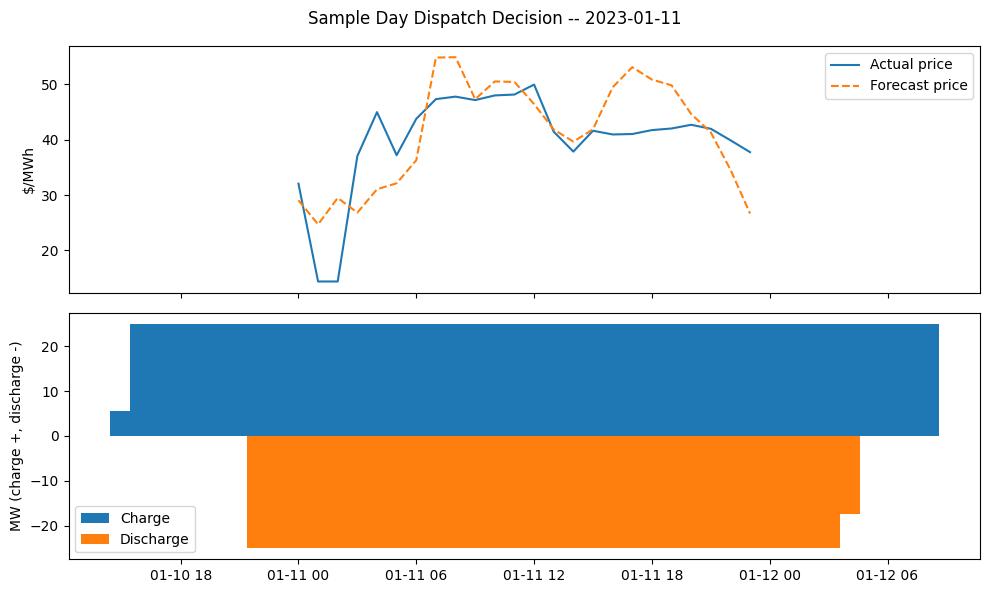

In [7]:
sample_day = test_2023[test_2023['datetime'].dt.date == results_2023['date'].iloc[10]].sort_values('datetime')
fc_charge, fc_discharge = optimize_battery_day(sample_day['price_forecast'].values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(sample_day['datetime'], sample_day['hoep'], label='Actual price')
ax1.plot(sample_day['datetime'], sample_day['price_forecast'], label='Forecast price', linestyle='--')
ax1.set_ylabel('$/MWh')
ax1.legend()

ax2.bar(sample_day['datetime'], fc_charge, label='Charge', color='tab:blue')
ax2.bar(sample_day['datetime'], -fc_discharge, label='Discharge', color='tab:orange')
ax2.set_ylabel('MW (charge +, discharge -)')
ax2.legend()

plt.suptitle(f'Sample Day Dispatch Decision -- {results_2023["date"].iloc[10]}')
plt.tight_layout()
plt.show()

## 4. Overall summary across all three years

          year      forecast     naive      perfect  pct_of_max
          2023 370113.844199 527527.00 9.820213e+05   37.688984
          2024 481495.949831 644141.50 1.262865e+06   38.127259
2025 (partial) 325017.416667 261760.25 8.782842e+05   37.005949


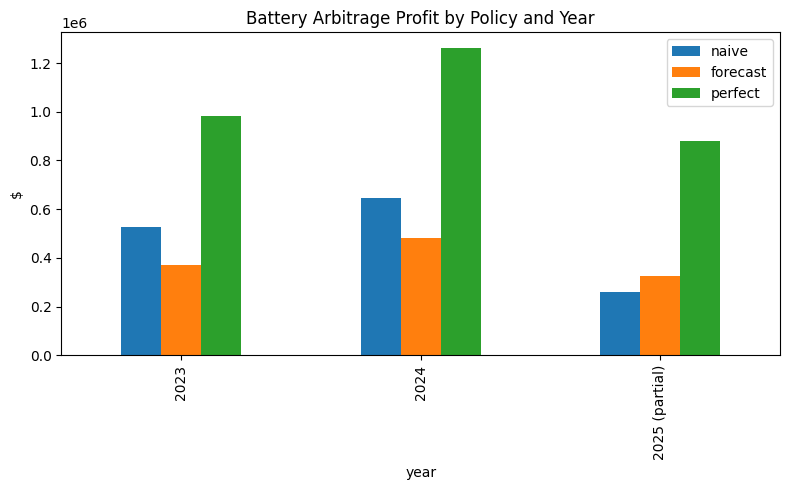

In [8]:
summary = pd.DataFrame([
    {'year': '2023', 'forecast': results_2023['forecast_profit'].sum(),
     'naive': results_2023['naive_profit'].sum(), 'perfect': results_2023['perfect_profit'].sum()},
    {'year': '2024', 'forecast': results_2024['forecast_profit'].sum(),
     'naive': results_2024['naive_profit'].sum(), 'perfect': results_2024['perfect_profit'].sum()},
    {'year': '2025 (partial)', 'forecast': results_2025['forecast_profit'].sum(),
     'naive': results_2025['naive_profit'].sum(), 'perfect': results_2025['perfect_profit'].sum()},
])
summary['pct_of_max'] = 100 * summary['forecast'] / summary['perfect']
print(summary.to_string(index=False))

summary.set_index('year')[['naive', 'forecast', 'perfect']].plot(kind='bar', figsize=(8, 5))
plt.title('Battery Arbitrage Profit by Policy and Year')
plt.ylabel('$')
plt.tight_layout()
plt.show()

In [9]:
def diagnose_policy(results_df, label):
    n_days = len(results_df)
    n_worse_than_naive = (results_df['forecast_profit'] < results_df['naive_profit']).sum()
    n_negative_profit = (results_df['forecast_profit'] < 0).sum()
    avg_regret = (results_df['perfect_profit'] - results_df['forecast_profit']).mean()

    print(f"--- {label} ---")
    print(f"  Days forecast policy underperformed naive: {n_worse_than_naive}/{n_days} ({100*n_worse_than_naive/n_days:.0f}%)")
    print(f"  Days forecast policy lost money outright:   {n_negative_profit}/{n_days} ({100*n_negative_profit/n_days:.0f}%)")
    print(f"  Average daily regret vs. perfect hindsight:  \${avg_regret:.0f}")
    print()

diagnose_policy(results_2023, '2023')
diagnose_policy(results_2024, '2024')
diagnose_policy(results_2025, '2025 (partial)')

--- 2023 ---
  Days forecast policy underperformed naive: 250/365 (68%)
  Days forecast policy lost money outright:   64/365 (18%)
  Average daily regret vs. perfect hindsight:  \$1676

--- 2024 ---
  Days forecast policy underperformed naive: 268/366 (73%)
  Days forecast policy lost money outright:   70/366 (19%)
  Average daily regret vs. perfect hindsight:  \$2135

--- 2025 (partial) ---
  Days forecast policy underperformed naive: 76/120 (63%)
  Days forecast policy lost money outright:   36/120 (30%)
  Average daily regret vs. perfect hindsight:  \$4611



## 5. Trying to improve results

Only trade on a given day if the forecasted price SPREAD (max - min) is
large enough to be worth trusting; otherwise sit idle for that day
entirely. The threshold itself is chosen using the 2022 validation slice
only, never by looking at the test years.

In [ ]:
val_df = train_df[train_df['datetime'] >= '2022-01-01'].copy()
val_df['date'] = val_df['datetime'].dt.date

# ****CAN DELETE USER NAIVE ARGUMENT??????****
def run_backtest_with_deadband(df, spread_threshold, use_naive_below_threshold=False):
    daily_results = []
    for date, day_df in df.groupby('date'):
        if len(day_df) != 24:
            continue
        day_df = day_df.sort_values('datetime')
        forecast_prices = day_df['price_forecast'].values
        actual_prices = day_df['hoep'].values
        spread = forecast_prices.max() - forecast_prices.min()

        if spread >= spread_threshold:
            charge, discharge = optimize_battery_day(forecast_prices)
        else:
            charge, discharge = np.zeros(24), np.zeros(24)  # sit idle - not worth trusting this forecast

        profit = evaluate_schedule(charge, discharge, actual_prices)
        daily_results.append({'date': date, 'profit': profit, 'spread': spread})

    return pd.DataFrame(daily_results)


# Sweep candidate thresholds on the validation set only, pick whichever total profit is highest
candidate_thresholds = [0, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]
threshold_results = []
for thresh in candidate_thresholds:
    val_result = run_backtest_with_deadband(val_df, thresh)
    threshold_results.append({'threshold': thresh, 'total_profit': val_result['profit'].sum()})

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)

best_threshold = threshold_df.loc[threshold_df['total_profit'].idxmax(), 'threshold']
print(f"\nChosen spread threshold: {best_threshold}")

for year_label, test_set in [('2023', test_2023), ('2024', test_2024), ('2025 (partial)', test_2025)]:
    test_set_copy = test_set.copy()
    test_set_copy['date'] = test_set_copy['datetime'].dt.date
    deadband_result = run_backtest_with_deadband(test_set_copy, best_threshold)

    original = {'2023': results_2023, '2024': results_2024, '2025 (partial)': results_2025}[year_label]
    total_deadband = deadband_result['profit'].sum()
    total_naive = original['naive_profit'].sum()
    total_perfect = original['perfect_profit'].sum()
    n_idle_days = (deadband_result['spread'] < best_threshold).sum()

    print(f"--- {year_label} ---")
    print(f"  Deadband policy:  \${total_deadband:,.0f}  ({n_idle_days}/{len(deadband_result)} days sat idle)")
    print(f"  Naive schedule:   \${total_naive:,.0f}")
    print(f"  Perfect hindsight: \${total_perfect:,.0f}")
    print(f"  Deadband captured {100*total_deadband/total_perfect:.1f}% of theoretical max")
    print(f"  Deadband vs naive: {'BEATS' if total_deadband > total_naive else 'still underperforms'} naive schedule")
    print()

    threshold   total_profit
0           0  910318.068970
1           5  910318.068970
2          10  906210.677311
3          15  906210.677311
4          20  890371.260648
5          25  842062.135666
6          30  766412.744039
7          40  605606.374633
8          50  491147.649711
9          75  263078.124837
10        100  125694.019380

Chosen spread threshold: 0


## Summary

1. The naive forecast-driven policy captured only ~37-38% of the
   theoretical maximum and, more concerningly, actually LOST to a
   simple fixed-time-of-day schedule on the majority of days.
2. Diagnosing why revealed price forecast error was causing actively
   wrong-direction trades (charging when actually expensive, discharging
   when actually cheap) on 18-30% of days. This was a materially different,
   more costly failure mode than plain forecast inaccuracy in a pure prediction
   task.
3. A confidence deadband (only trade when forecasted price spread is
   large enough to trust) was proposed and tested on the 2022 validation
   set before touching the test years. The validation evidence did not
   support it because profit decreased monotonically as the threshold rose,
   meaning "always trade" outperformed any deadband on that year